<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/Study3_cog_load_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-2-74a7c519caa0>:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pair', y='Statistic', data=pairwise_df, palette='Blues', ci=None)
<ipython-input-2-74a7c519caa0>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pair', y='Statistic', data=pairwise_df, palette='Blues', ci=None)


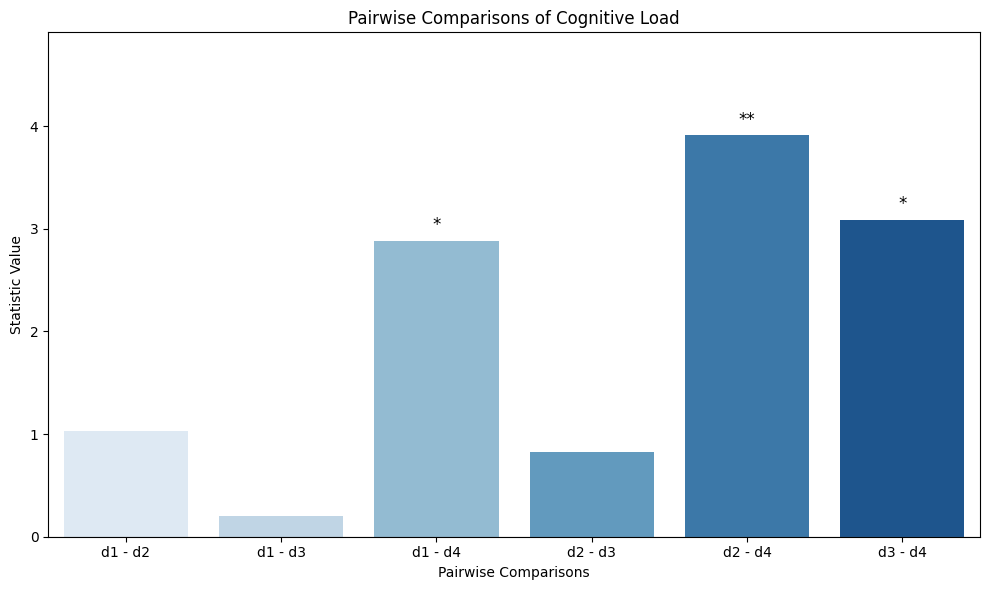

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data creation
pairwise_data = {
    "Pair": ["d1 - d2", "d1 - d3", "d1 - d4", "d2 - d3", "d2 - d4", "d3 - d4"],
    "Statistic": [1.030, 0.206, 2.885, 0.824, 3.915, 3.091],
    "p_value": [0.330, 0.841, 0.018, 0.431, 0.004, 0.013]
}

# Create a DataFrame
pairwise_df = pd.DataFrame(pairwise_data)

# Add significance stars based on p-value thresholds
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

pairwise_df['Significance'] = pairwise_df['p_value'].apply(significance_stars)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Pair', y='Statistic', data=pairwise_df, palette='Blues', ci=None)

# Add significance stars to the plot
for index, row in pairwise_df.iterrows():
    plt.text(index, row.Statistic + 0.1, row.Significance, ha='center', fontsize=12)

# Labels and title
plt.xlabel('Pairwise Comparisons')
plt.ylabel('Statistic Value')
plt.title('Pairwise Comparisons of Cognitive Load')
plt.axhline(0, color='gray', lw=0.8)
plt.ylim(0, pairwise_df['Statistic'].max() + 1)

# Show plot
plt.tight_layout()
plt.show()
